# Visualizacao obrigatoria

Este notebook gera visualizacoes simples em texto/Matplotlib para caminhos encontrados, trajetoria online e rota da busca local.

In [1]:
from pathlib import Path
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

BASE = Path.cwd()
if BASE.name == "notebooks":
    BASE = BASE.parent
DATA = BASE / "datasets"
MAZES_DIR = DATA / "mazes"

def parse_caminho(valor):
    try:
        return ast.literal_eval(valor)
    except Exception:
        return []

def carregar_grid(maze_id):
    caminho = MAZES_DIR / f"{maze_id}.txt"
    return [list(linha.rstrip("\n")) for linha in caminho.read_text().splitlines()]

def desenhar_grid(grid, caminho=None, titulo="Labirinto"):
    caminho = caminho or []
    caminho_set = set(caminho)
    matriz = []
    for y, linha in enumerate(grid):
        row = []
        for x, celula in enumerate(linha):
            coord = (x, y)
            if coord in caminho_set:
                row.append(4)
            elif celula == "#":
                row.append(0)
            elif celula == "A":
                row.append(2)
            elif celula == "B":
                row.append(3)
            elif celula == "C":
                row.append(5)
            else:
                row.append(1)
        matriz.append(row)

    cmap = ListedColormap(["black", "white", "green", "red", "royalblue", "orange"])
    plt.figure(figsize=(8, 6))
    plt.imshow(matriz, cmap=cmap, interpolation="nearest")
    plt.title(titulo)
    plt.axis("off")
    plt.show()

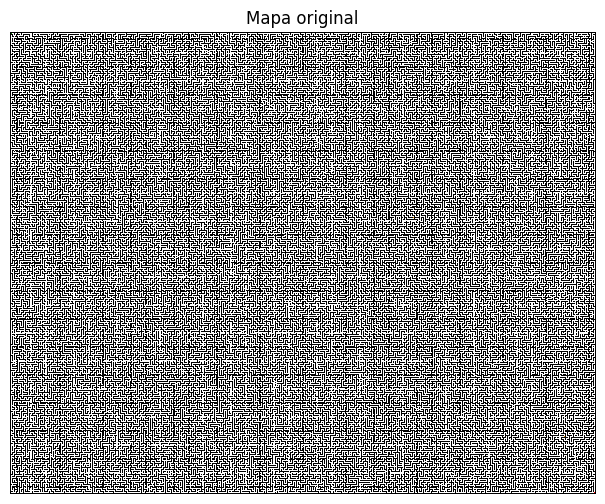

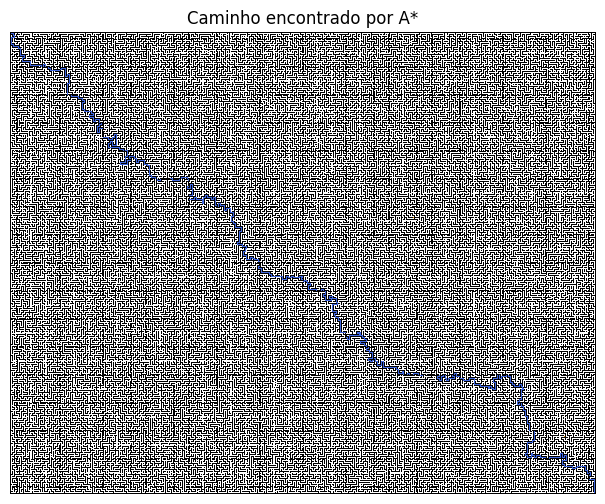

In [2]:
# 1. Mapa original e caminho encontrado por A*.
astar = pd.read_csv(DATA / "resultado_a_star.csv")
exemplo = astar.iloc[0]
grid = carregar_grid(exemplo["maze_id"])
caminho = parse_caminho(exemplo["caminho"])

desenhar_grid(grid, titulo="Mapa original")
desenhar_grid(grid, caminho=caminho, titulo="Caminho encontrado por A*")

In [3]:
# 2. Trajetoria online passo a passo em texto.
# Ajuste INDICE_FRAME para observar outro ponto da trajetoria.
online = pd.read_csv(DATA / "resultado_online_a_star.csv")
exemplo_online = online.iloc[0]
grid_online = carregar_grid(exemplo_online["maze_id"])
caminho_online = parse_caminho(exemplo_online["caminho"])
INDICE_FRAME = min(20, len(caminho_online) - 1)

percorrido = set(caminho_online[:INDICE_FRAME])
atual = caminho_online[INDICE_FRAME]
for y, linha in enumerate(grid_online):
    chars = []
    for x, celula in enumerate(linha):
        coord = (x, y)
        if coord == atual:
            chars.append("@")
        elif coord in percorrido:
            chars.append(".")
        else:
            chars.append(celula)
    print("".join(chars))

#########################################################################################################################################################################
#...  #               #         #   #       #       #   #       #         #   #         #     #               #       #             #       #     #   #   #             #
###.# ### #### # #### # # ##### # ### # ### # # ### # ### ### # ##### ### # # # # ##### ### # ##### ### # # ### ### # ####### # ###   # # # ### # # #   # # # # ### # # #
# ..# #   # #       #         # # #   #     # #   # # #   # # #   #       # #     #         #     #                       #     # # # # #           # # #   #         # #
# .##   # # # # ### ####### ### # # ### # ##### # # # # # # # ### # ####### ## ## # # # ### ##### ####### # # # # ####### # ##### # ###   # # # # # ### ####### ####### #
# .   # #   # #   #       #     #     # #       # # # #     #   #         #         # #         #     #   # #   #       #   #       #   #   #   #   # 

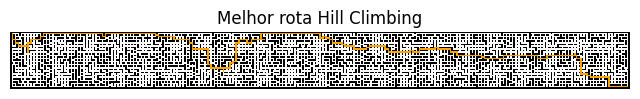

In [4]:
# 3. Rota otimizada da busca local.
hc = pd.read_csv(DATA / "resultados_hill_climbing.csv")
melhor_hc = hc.loc[hc["custo"].idxmin()]
grid_hc = carregar_grid(melhor_hc["maze_id"])
caminho_hc = parse_caminho(melhor_hc["caminho"])
desenhar_grid(grid_hc, caminho=caminho_hc, titulo="Melhor rota Hill Climbing")

## Dados faltantes para visualizacao completa

- O trabalho pede mostrar nos expandidos ou visitados. Os CSVs atuais salvam o caminho final, mas nao salvam a lista de todos os nos expandidos/visitados. Para uma visualizacao fiel, os algoritmos precisam gravar esse historico.
- O online nao salva o mapa interno final nem os mapas internos por passo. A celula acima reconstrui apenas a trajetoria, nao a evolucao completa do conhecimento do agente.
- Os CSVs de busca local salvam `curva_convergencia` e caminho final, mas nao salvam todos os estados candidatos testados.